In [2]:
from google.colab import drive 
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Thay đổi đường dẫn tới thư mục chứa file zip của bạn trên Drive
!ls "/content/drive/MyDrive/VQAv2/"

data.zip


In [4]:
!pwd

/content


In [5]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from sklearn.feature_extraction.text import TfidfVectorizer #
import torchvision.transforms as transforms #
import random
import numpy as np
import matplotlib.pyplot as plt
import timm
from collections import Counter #

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [7]:
class VQADataset(Dataset):
    def __init__(self, json_path, data_dir, transform=None, vocab=None):
        with open(json_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        self.data_dir = data_dir
        self.transform = transform
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        img_path = os.path.join(self.data_dir, item['image_path'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        question = item['question']

        answer = item['answer']
        answer_idx = self.vocab.get(answer, -1)
        answers = item.get('answers', [answer])

        return {
            'image': image,
            'question': question,
            'answer': answer_idx,
            'raw_answer': answer,
            'answers': answers
            }

In [8]:
def get_transforms(img_size=1024):
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

In [9]:
def build_answer_vocab(train_data, val_data, max_answers=10000):
    all_answers = []
    for item in train_data:
        all_answers.extend(item.get("answers", [item["answer"]]))

    for item in val_data:
        all_answers.extend(item.get("answers", [item["answer"]]))

    answer_counts = Counter(all_answers)
    unique_answers = list(answer_counts.keys())

    if len(unique_answers) > max_answers:
        unique_answers = [ans for ans,_ in answer_counts.most_common(max_answers)]

    vocab = {ans: idx for idx, ans in enumerate(sorted(unique_answers))}
    
    print(f"Build vocab: {len(vocab)} answers")

    return vocab


In [10]:
data_dir = './data/vqav2'
batch_size = 32
img_size = 224
tfidf_dim = 1000

In [11]:
!unzip -q "./drive/MyDrive/data.zip" -d /content/

In [12]:
!ls "./data/vqav2"

images	test.json  train.json  val.json


In [13]:
train_transform, val_transform = get_transforms(img_size=img_size)

with open(os.path.join(data_dir, 'train.json'), 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open(os.path.join(data_dir, 'val.json'), 'r', encoding='utf-8') as f:
    val_data = json.load(f)

vocab = build_answer_vocab(train_data, val_data)
num_classes = len(vocab)
idx_to_ans = {idx: ans for ans, idx in vocab.items()}

print(f'Number of classes: {num_classes}')
print(f'Number of classes: {len(idx_to_ans)}')

Build vocab: 4611 answers
Number of classes: 4611
Number of classes: 4611


In [14]:
train_dataset = VQADataset(
    json_path=os.path.join(data_dir, 'train.json'),
    data_dir=data_dir,
    transform=train_transform,
    vocab=vocab
)

val_dataset = VQADataset(
    json_path=os.path.join(data_dir, 'val.json'),
    data_dir=data_dir,
    transform=val_transform,
    vocab=vocab
)

test_dataset = VQADataset(
    json_path=os.path.join(data_dir, 'test.json'),
    data_dir=data_dir,
    transform=val_transform,
    vocab=vocab
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [15]:
all_questions = []
for batch in train_loader:
    all_questions.extend(batch['question'])

word_set = set()
for q in all_questions:
    words = q.lower().split()
    word_set.update(words)

word_to_idx = {'<PAD>': 0, '<UNK>': 1}
for idx, word in enumerate(sorted(word_set), start=2):
    word_to_idx[word] = idx

vocab_size = len(word_to_idx)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 2311


# 3. Xây dựng Mô hình

In [16]:
class CNN_LSTM_Baseline(nn.Module):
    def __init__(self, num_classes, vocab_size, word_to_idx, hidden_dim=512,lstm_layers=2, embed_dim=300, max_len=64):
        super().__init__()

        self.cnn = timm.create_model('resnet50', pretrained=True, num_classes=0)
        for param in self.cnn.parameters():
            param.requires_grad = False
        cnn_output_dim = self.cnn.num_features

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, lstm_layers, batch_first=True, bidirectional=True)
        lstm_output_dim = hidden_dim * 2

        fusion_dim = cnn_output_dim + lstm_output_dim
        self.bottleneck = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.classifier = nn.Linear(hidden_dim, num_classes)

        self.word_to_idx = word_to_idx
        self.max_len = max_len

    def tokenize(self, questions):
        batch_tokens = []
        for q in questions:
            words = q.lower().split()
            tokens = [self.word_to_idx.get(w, 1) for w in words]

            if len(tokens) < self.max_len:
                tokens = tokens + [0] * (self.max_len - len(tokens))
            else:
                tokens = tokens[:self.max_len]
            
            batch_tokens.append(tokens)

        return torch.LongTensor(batch_tokens)

    def forward(self, images, questions):
        img_features = self.cnn(images)

        question_tokens = self.tokenize(questions).to(images.device)
        question_embeds = self.embedding(question_tokens)
        lstm_out, (hidden, cell) = self.lstm(question_embeds)
        text_features = torch.cat([hidden[-2], hidden[-1]], dim=1)

        combined = torch.cat([img_features, text_features], dim=1)
        fused_features = self.bottleneck(combined)
        output = self.classifier(fused_features)

        return output

In [17]:
def compute_vqa_accuracy(prediction, ground_truth_answers):
    if not ground_truth_answers:
        return 0.0
    
    count = 0
    pred = prediction.lower().strip()
    
    for ans in ground_truth_answers:
        if ans.lower().strip() == pred:
            count += 1
    
    return min(1.0, count/3.0)

In [18]:
def levenshtein_distance(s1, s2):
    if len(s1) > len(s2):
        s1, s2 = s2, s1

    distances = range(len(s1) + 1)
    for i2, c2 in enumerate(s2):
        distances_ = [i2+1]
        for i1, c1 in enumerate(s1):
            if c1 == c2:
                distances_.append(distances[i1])
            else:
                distances_.append(1 + min((distances[i1], distances[i1 + 1], distances_[-1])))
        distances = distances_
    return distances[-1]

In [19]:
def compute_anls(target, prediction):
    target = target.lower().strip()
    prediction = prediction.lower().strip()

    if not target or not prediction:
        return 0.0 if target != prediction else 1.0

    dist = levenshtein_distance(target, prediction)
    max_len = max(len(target), len(prediction))

    score = 1.0 - float(dist) / float(max_len)
    return score if score >= 0.5 else 0.0

In [20]:
def train_epoch(model, dataloader, criterion, optimizer, device, idx_to_ans):
    model.train()
    total_loss = 0
    sum_vqa_acc = 0
    total_samples = 0

    for batch in dataloader:
        images = batch['image'].to(device)
        questions = batch['question']
        answers = batch['answer'].to(device)
        raw_answers = batch['raw_answer']
        gt_answers_list = batch.get('answers', [[ans] for ans in raw_answers])

        if isinstance(gt_answers_list, list) and len(gt_answers_list) > 0 and isinstance(gt_answers_list[0], (list, tuple)):
            gt_answers_list = list(zip(*gt_answers_list))

        valid_mask = answers != -1
        if not valid_mask.any():
            continue

        optimizer.zero_grad()
        outputs = model(images, questions)

        v_outputs = outputs[valid_mask]
        v_answers = answers[valid_mask]
        loss = criterion(v_outputs, v_answers)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * v_answers.size(0)
        batch_size = images.size(0)
        total_samples += batch_size

        _, predicted = outputs.max(1)
        for i in range(batch_size):
            pred_id = predicted[i].item()
            pred_text = idx_to_ans.get(pred_id, "")
            gt_list = gt_answers_list[i]
            sum_vqa_acc += compute_vqa_accuracy(pred_text, gt_list)
    
    avg_loss = total_loss / total_samples if total_samples > 0 else 0
    vqa_acc = 100. * sum_vqa_acc / total_samples if total_samples > 0 else 0

    return avg_loss, vqa_acc

In [21]:
def evaluate(model, dataloader, criterion,  device, idx_to_ans):
    model.eval()

    total_loss = 0

    correct_top1 = 0
    correct_top5 = 0
    total_valid_vocab = 0

    sum_vqa_acc = 0
    sum_vqa_top5 = 0

    sum_anls = 0
    total_samples = 0

    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            questions = batch['question']
            answers = batch['answer'].to(device)
            raw_answers = batch['raw_answer']
            gt_answers_list = batch.get('answers', [[ans] for ans in raw_answers])

            if isinstance(gt_answers_list, list) and len(gt_answers_list) > 0 and isinstance(gt_answers_list[0], (list, tuple)):
                gt_answers_list = list(zip(*gt_answers_list))

            batch_size = images.size(0)
            total_samples += batch_size

            valid_mask = answers != -1
            if not valid_mask.any():
                continue

            outputs = model(images, questions)
            v_outputs = outputs[valid_mask]
            v_answers = answers[valid_mask]
            loss = criterion(v_outputs, v_answers)
            total_loss += loss.item() * v_answers.size(0)

            _, predicted = v_outputs.max(1)
            correct_top1 += predicted.eq(v_answers).sum().item()

            _, top5_preds = v_outputs.topk(min(5, v_outputs.size(1)), 1)
            correct_top5 += (top5_preds == v_answers.view(-1, 1)).sum().item()

            total_valid_vocab += valid_mask.sum().item()

            _, top5_all = outputs.topk(min(5, outputs.size(1)), 1)

            for i in range(batch_size):
                pred_id = top5_all[i, 0].item()
                pred_text_top1 = idx_to_ans.get(pred_id, "")
                gt_list = gt_answers_list[i]

                # Top-1 VQA
                sum_vqa_acc += compute_vqa_accuracy(pred_text_top1, gt_list)

                # Top-5 VQA: max VQA score among top 5
                vqa_scores_top5 = [compute_vqa_accuracy(idx_to_ans.get(top5_all[i, j].item(), ""), gt_list) for j in range(top5_all.size(1))]
                sum_vqa_top5 += max(vqa_scores_top5)

                # ANLS (Top-1)
                sum_anls += compute_anls(raw_answers[i], pred_text_top1)

    avg_loss = total_loss / total_valid_vocab if total_samples > 0 else 0
    acc_top1 = 100. * correct_top1 / total_valid_vocab if total_valid_vocab > 0 else 0
    acc_top5 = 100. * correct_top5 / total_valid_vocab if total_valid_vocab > 0 else 0

    vqa_acc = 100. * sum_vqa_acc / total_samples if total_samples > 0 else 0
    vqa_top5 = 100. * sum_vqa_top5 / total_samples if total_samples > 0 else 0
    avg_anls = sum_anls / total_samples if total_samples > 0 else 0


    return avg_loss, acc_top1, acc_top5, vqa_acc, vqa_top5, avg_anls

In [22]:
hidden_dim = 512
lstm_layers = 2
embed_dim = 300
max_len = 64

model = CNN_LSTM_Baseline(
    num_classes=num_classes,
    vocab_size=vocab_size,
    word_to_idx=word_to_idx,
    hidden_dim=hidden_dim,
    lstm_layers=lstm_layers,
    embed_dim=embed_dim,
    max_len=max_len
).to(device)

print("Model initialized successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model initialized successfully


In [23]:
num_epochs = 10
lr = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [24]:
history = {"train_loss": [], 
            "train_acc": [],
            "val_loss": [],
            "val_acc": []
            }

In [25]:
def plot_training_history(history, save_path='training_history.pdf', model_name='Model'):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot Loss
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    ax1.plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'{model_name} - Training & Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Plot Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2, markersize=4)
    ax2.plot(epochs, history['val_acc'], 'r-s', label='Val Acc', linewidth=2, markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title(f'{model_name} - Training & Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_final_results(train_acc, val_acc, test_acc, save_path='final_results.pdf', model_name='Model'):
    splits = ['Train', 'Validation', 'Test']
    accuracies = [train_acc, val_acc, test_acc]
    colors = ['steelblue', 'coral', 'mediumseagreen']

    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(splits, accuracies, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.annotate(f'{acc:.2f}%',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=12, fontweight='bold')

    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} - Final Results', fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(accuracies) * 1.15)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [26]:
best_vqa_acc = 0
best_epoch = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, idx_to_ans)

    val_metrics = evaluate(model, val_loader, criterion, device, idx_to_ans)
    val_loss, val_acc, val_top5, val_vqa, val_vqa_top5, val_anls = val_metrics

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_vqa)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val VQA Acc: {val_vqa:.2f}%, Val VQA Top5: {val_vqa_top5:.2f}%, Val ANLS: {val_anls:.4f}")

    if val_vqa > best_vqa_acc:
        best_vqa_acc = val_vqa
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vqa_acc': val_vqa,
            'vqa_top5': val_vqa_top5,
            'anls': val_anls,
        }, 'cnn_lstm_best.pth')
        print(f"Saved best model with VQA Acc: {val_vqa:.2f}%")

Epoch 1/10
Train Loss: 4.1926, Train Acc: 7.95%
Val VQA Acc: 17.63%, Val VQA Top5: 54.83%, Val ANLS: 0.1813
Saved best model with VQA Acc: 17.63%
Epoch 2/10
Train Loss: 2.9178, Train Acc: 21.65%
Val VQA Acc: 31.40%, Val VQA Top5: 71.97%, Val ANLS: 0.2927
Saved best model with VQA Acc: 31.40%
Epoch 3/10
Train Loss: 2.3224, Train Acc: 34.00%
Val VQA Acc: 40.33%, Val VQA Top5: 75.60%, Val ANLS: 0.3958
Saved best model with VQA Acc: 40.33%
Epoch 4/10
Train Loss: 1.9407, Train Acc: 41.65%
Val VQA Acc: 43.50%, Val VQA Top5: 76.63%, Val ANLS: 0.4300
Saved best model with VQA Acc: 43.50%
Epoch 5/10
Train Loss: 1.6649, Train Acc: 48.89%
Val VQA Acc: 49.33%, Val VQA Top5: 79.67%, Val ANLS: 0.4817
Saved best model with VQA Acc: 49.33%
Epoch 6/10
Train Loss: 1.4766, Train Acc: 54.22%
Val VQA Acc: 48.80%, Val VQA Top5: 80.27%, Val ANLS: 0.4873
Epoch 7/10
Train Loss: 1.3414, Train Acc: 57.81%
Val VQA Acc: 49.77%, Val VQA Top5: 83.47%, Val ANLS: 0.4945
Saved best model with VQA Acc: 49.77%
Epoch 8/10

In [33]:
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'vqa_acc': val_vqa,
    'vqa_top5': val_vqa_top5,
    'anls': val_anls,
}, './drive/MyDrive/VQAv2/cnn_lstm_best.pth')

In [34]:
checkpoint = torch.load('./drive/MyDrive/VQAv2/cnn_lstm_best.pth', map_location=device)

model_loaded = CNN_LSTM_Baseline(
    num_classes=num_classes,
    vocab_size=vocab_size,
    word_to_idx=word_to_idx,
    hidden_dim=hidden_dim,
    lstm_layers=lstm_layers,
    embed_dim=embed_dim,
    max_len=max_len
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

print(f"Loaded model from epoch: {checkpoint['epoch'] + 1}")
print(f"Saved VQA Acc: {checkpoint['vqa_acc']:.2f}%")
print(f"Saved VQA Top5: {checkpoint['vqa_top5']:.2f}%")
print(f"Saved ANLS: {checkpoint['anls']:.4f}")

test_metrics = evaluate(model_loaded, test_loader, criterion, device, idx_to_ans)
test_loss, test_acc, test_top5, test_vqa, test_vqa_top5, test_anls = test_metrics

print(f"\nTest VQA Acc: {test_vqa:.2f}%")
print(f"Test VQA Top5: {test_vqa_top5:.2f}%")
print(f"Test ANLS: {test_anls:.4f}")

Loaded model from epoch: 10
Saved VQA Acc: 51.33%
Saved VQA Top5: 82.77%
Saved ANLS: 0.5077

Test VQA Acc: 56.90%
Test VQA Top5: 83.30%
Test ANLS: 0.5626


In [35]:
test_metrics = evaluate(model, test_loader, criterion, device, idx_to_ans)
test_loss, test_acc, test_top5, test_vqa, test_vqa_top5, test_anls = test_metrics
print(f"Test VQA Acc: {test_vqa:.2f}%, Test VQA Top5: {test_vqa_top5:.2f}%, Test ANLS: {test_anls:.4f}")

Test VQA Acc: 56.90%, Test VQA Top5: 83.30%, Test ANLS: 0.5626


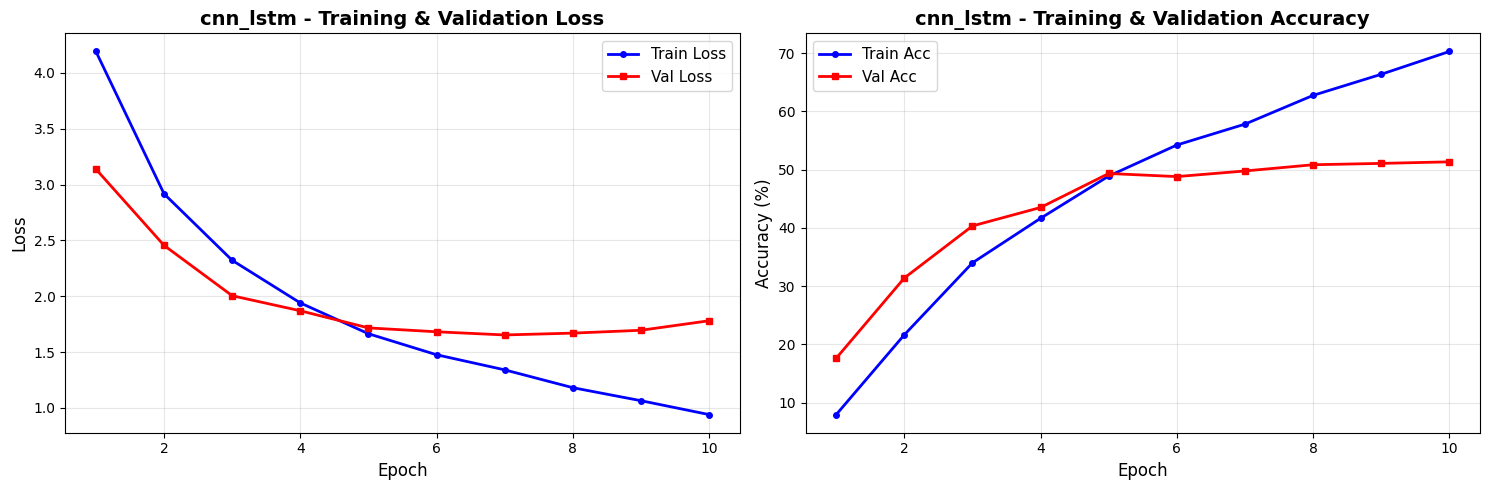

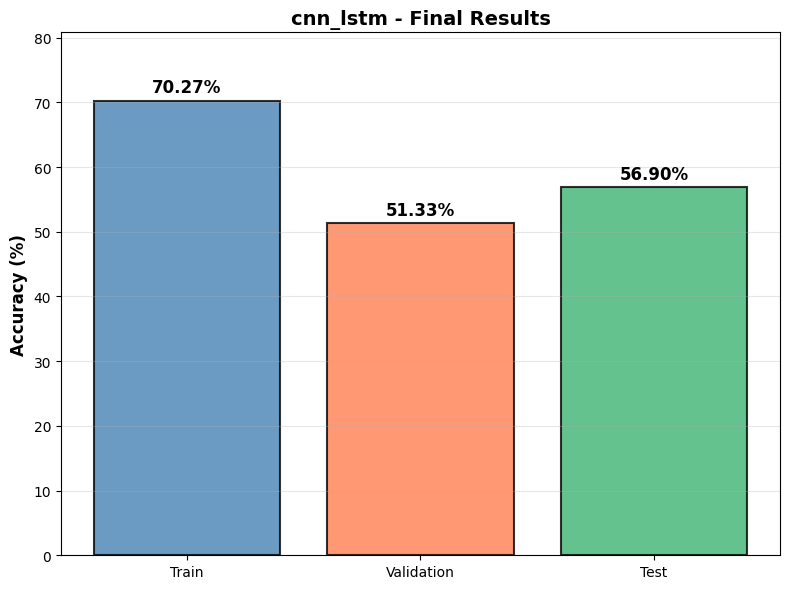

In [ ]:
plot_training_history(history, save_path='cnn_lstm_history.pdf', model_name='cnn_lstm')
plot_final_results(history['train_acc'][-1], best_vqa_acc, test_vqa,
                  save_path='CNN_LSTM_results.pdf', model_name='cnn_lstm')